In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [8]:
# STEP 1: Create a synthetic regression dataset

# n_samples  -> number of data points
# n_features -> number of input features
# noise      -> adds randomness to make data realistic

X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
X.shape

(200, 1)

In [9]:
# X is returned as a 2D array: shape (200, 1)
# Convert to 1D for easier mathematical implementation
X = X.flatten()
X.shape

(200,)

In [10]:
# STEP 2: Train-test split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [28]:
# STEP 3: Linear Regression from Scratch

class LinearRegressionScratch:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        # Mean of X and Y
        x_mean = np.mean(X_train)
        y_mean = np.mean(y_train)

        # Equation 1
        # m = Σ[(xi - x̄)(yi - ȳ)] / Σ[(xi - x̄)^2]

        self.m = np.sum((X_train - x_mean) * (y_train - y_mean)) / np.sum((X_train - x_mean) ** 2)

        # Equation 2:
        # b = ȳ - m x̄

        self.b = y_mean - self.m * x_mean

    def predict(self, X):
        # Equation 3:
        # ŷ = mx + b
        
        return self.m * X + self.b

In [29]:
# Train the model
lnr = LinearRegressionScratch()
lnr.fit(X_train, y_train)

print("Slope (m):", lnr.m)
print("Intercept (b):", lnr.b)

Slope (m): 86.81798328085429
Intercept (b): 1.8345766385094247


In [30]:
# Predict 
y_pred = lnr.predict(X_test)
print(y_test.shape)
print(y_pred.shape)

(40,)
(40,)


In [31]:
# Evaluation

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score: 0.9680853989031325
MSE: 246.12179288664493
RMSE: 15.688269276330162


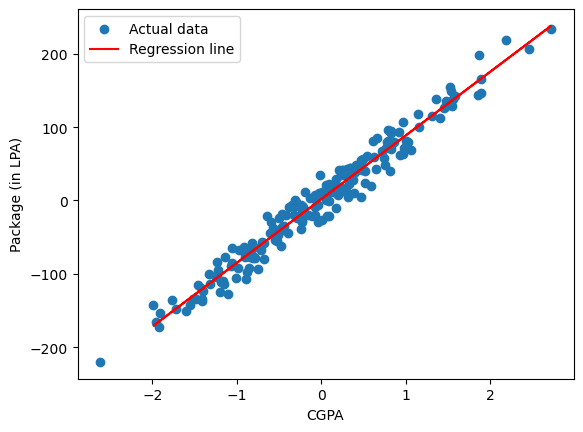

In [33]:
# Plot

plt.scatter(X, y, label="Actual data")
plt.plot(X_train, lnr.predict(X_train), color="red", label="Regression line")
plt.xlabel("CGPA")
plt.ylabel("Package (in LPA)")
plt.legend()
plt.show()